
At very first, we try ClusPro, LightDock and HADDOCK3 using 1LP1, 3MZW, 5DJT, 5DJU and 5EFW these 5 native affibody complexes (crystal structure)

We could only use ClusPro on web server
For LightDock we use blinded LightDock

Here are the codes on how I use ClusPro, LightDock and HADDOCK3 these 3 tools. 

Blinded LightDock

Firstly, we need to install LightDock for using. 

conda create -n lightdock311 python=3.11
conda activate lightdock311
pip install lightdock


sbatch ./run_lightdock.sh

Tips: you can see "run_lightdock.sh" file in this repository and it need to be edited every time as we need to change data for different complex. 


HADDOCK3

conda create -n haddock3 python=3.10
conda activate haddock3
pip install haddock3

sbatch ./run_haddock3.sh

Tips: this also need to be edited everytime as we need to change run_dir, molecules and chains three parts in cfg file for each structure.
ref: https://github.com/haddocking/haddock3/blob/main/examples/docking-protein-protein/docking-protein-protein-full.cfg
     https://www.bonvinlab.org/haddock3/modules/scoring/haddock.modules.scoring.prodigyprotein.html

I uploaded the top structure generated from each tool into the repository and at that time we calculated the DockQ score to have a comparison. The results collected in comparison.csv and here are the code and plot on visualization. 

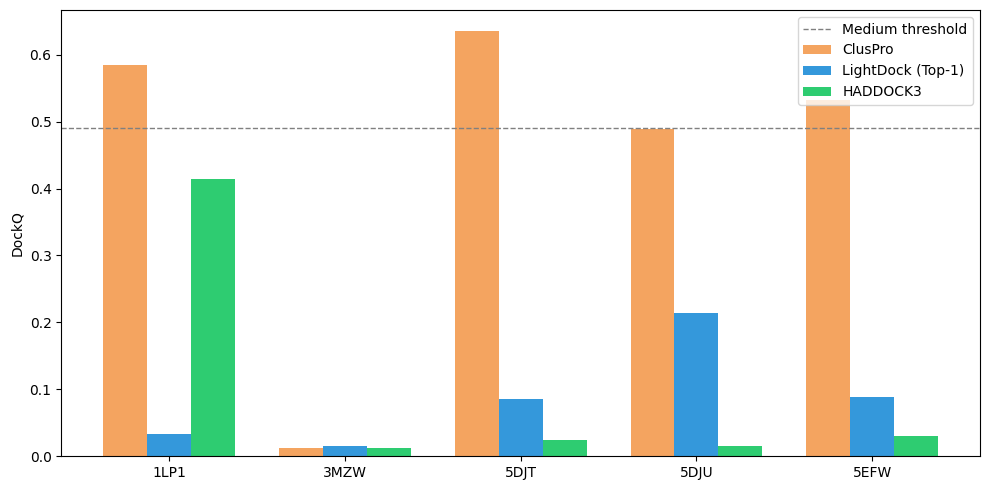

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/home/mc2571/repos/sabdl/notebooks/Docking/comparison.csv")

targets = df["Target"]
x = np.arange(len(targets))
width = 0.25

plt.figure(figsize=(10, 5))

plt.bar(x - width, df["ClusPro"], width, label="ClusPro", color="#F4A460")
plt.bar(x, df["LightDock"], width, label="LightDock (Top-1)", color="#3498db")
plt.bar(x+ width, df["HADDOCK3"], width, label="HADDOCK3", color="#2ecc71")

# Threshold for acceptable quality
plt.axhline(0.49, linestyle="--", color="gray", linewidth=1, label="Medium threshold")

plt.xticks(x, targets)
plt.ylabel("DockQ")
plt.legend()
plt.tight_layout()
plt.show()
